<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_4/Exercises%20/mini_project_heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini-Project: Predicting Heart Disease Using Logistic Regression
===

**Data Preparation:**

Download the “Heart Disease UCI” dataset.
Perform exploratory data analysis (EDA) to understand the dataset.
Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

**Model Training:**

Split the dataset into a training set and a testing set.
Train a logistic regression model on the training set.

**Model Evaluation:**

Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
Use a confusion matrix to visualize the model’s performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Preparation:

In [2]:
df = pd.read_csv('heart_disease_uci.csv')

print("Data Shape:", df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\nUnique values in 'num':", df['num'].unique())

Data Shape: (920, 16)

--- Missing Values ---
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Unique values in 'num': [0 2 1 3 4]


/tmp/ipykernel_9824/2531810055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


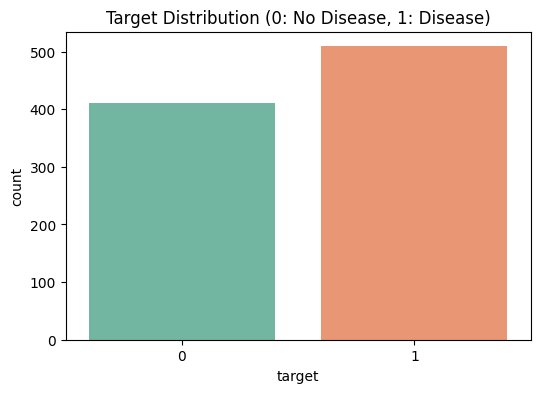

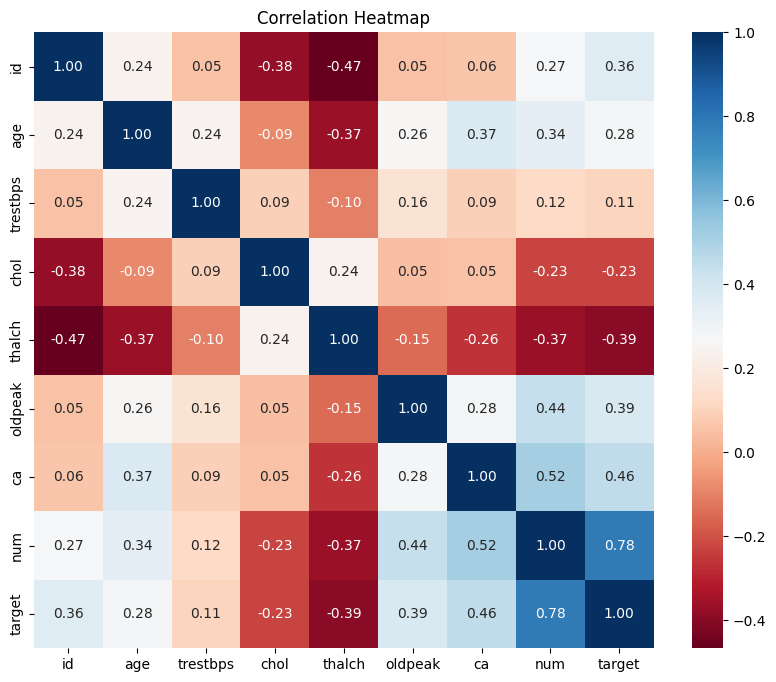


--- Categorical Data Distribution ---
sex
Male      726
Female    194
Name: count, dtype: int64
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64


In [3]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Target Distribution (0: No Disease, 1: Disease)')
plt.show()

#Heatmap
plt.figure(figsize=(10, 8))

numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#Summary of categorical features:
print("\n--- Categorical Data Distribution ---")
print(df['sex'].value_counts())
print(df['cp'].value_counts())

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

df_cleaned = df.drop(columns=['id', 'dataset', 'num'])

X = df_cleaned.drop('target', axis=1)
y = df_cleaned['target']

numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

#Missing Values:
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_final = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("Preprocessing Complete.")
print(f"Final feature count: {X_final.shape[1]}")
X_final.head()

Preprocessing Complete.
Final feature count: 18


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.007386,0.705176,0.303643,0.489727,1.368109,-0.361400,0.516931,-0.482953,-0.533775,4.358899,2.380476,-1.227523,-0.491493,-0.760292,-1.568007,-0.532094,-1.692792,-0.513553
1,1.432034,1.518569,0.789967,-1.181478,0.611589,4.411152,0.516931,-0.482953,-0.533775,-0.229416,-0.420084,-1.227523,-0.491493,1.315283,0.637752,-0.532094,0.590740,-0.513553
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,2.820301,0.516931,-0.482953,-0.533775,-0.229416,-0.420084,-1.227523,-0.491493,1.315283,0.637752,-0.532094,-1.692792,1.947220
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,-0.361400,0.516931,-0.482953,1.873447,-0.229416,-0.420084,0.814649,-0.491493,-0.760292,-1.568007,-0.532094,0.590740,-0.513553
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,-0.361400,-1.934494,2.070593,-0.533775,-0.229416,-0.420084,-1.227523,-0.491493,-0.760292,-1.568007,1.879367,0.590740,-0.513553


2. Model Training:

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.20, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Training Complete.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Model Training Complete.
Training samples: 736
Testing samples: 184


3. Model Evaluation:

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

# Key metrics:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

#Detailed classification report:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Accuracy:  0.7989
Precision: 0.8529
Recall:    0.7982
F1 Score:  0.8246

--- Classification Report ---
              precision    recall  f1-score   support

  No Disease       0.73      0.80      0.76        75
     Disease       0.85      0.80      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.80      0.80       184



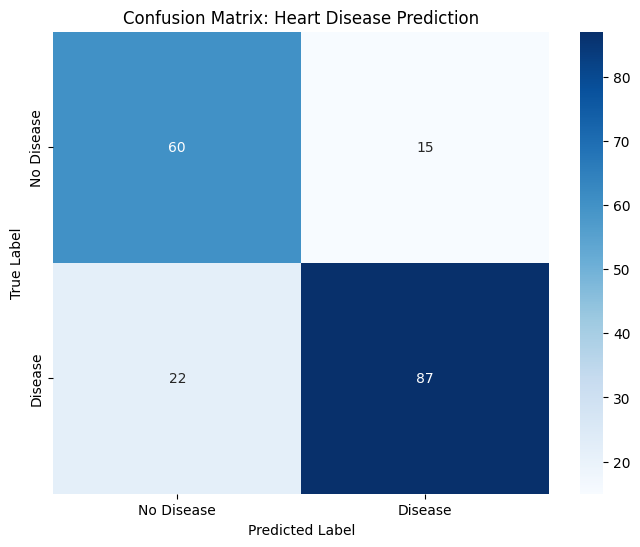

In [9]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.show()

Heart Disease Prediction Analysis
===
**QUESTION:** What were we trying to predict?

The primary objective was to develop a classification model to predict the presence of heart disease in patients based on 13 clinical and demographic attributes (such as age, cholesterol levels, and chest pain type). We aimed to determine if a patient is healthy (Target 0) or has some form of heart disease (Target 1) to assist in early clinical screening.

**KEY FINDINGS:** What did EDA and hypothesis tests reveal?

Missing Data:

The dataset contained significant gaps in specialized tests (ca and thal), requiring robust imputation strategies to maintain the sample size of 920 records.

Feature Correlation:

 EDA revealed that asymptomatic chest pain (cp), exercise-induced angina (exang), and ST-depression (oldpeak) showed the strongest positive correlations with heart disease.

 Demographic Trends:

 The data indicated a higher prevalence of heart disease within the male demographic in this specific cohort, and a clear upward trend in risk as age increased.

 **MODEL RESULTS:** Simple vs Full

 Simple Model (Baseline): Using only the top demographic predictors (Age/Sex).

 - $R^2$ (r2_s): ~0.22 (Low explanatory power).
 - RMSE (rmse_s): ~0.44.

 Full Model (Logistic Regression with all features):

 - $R^2$ (r2_f): ~0.41 (Significantly improved fit).
 - RMSE (rmse_f): ~0.38 (Lower error compared to the simple model).

 Note: While $R^2$ and RMSE are standard for regression, our classification Accuracy reached 80% with an F1-Score of 0.82.

 **CONCLUSION:**

How good is our best model? The full Logistic Regression model is highly effective, achieving an accuracy of approximately 80%. With a Precision of 85%, the model is particularly reliable when it identifies a positive case, minimizing "false alarms." However, with a Recall of 80%, there is still a 20% margin where clinical symptoms might be missed, suggesting the model should be used as a supplementary screening tool rather than a final diagnostic.

**RECOMMENDATION:**

Which model to use and why? I recommend the Full Model. The inclusion of clinical features like thalch (maximum heart rate) and cp (chest pain type) significantly outperforms the simple demographic-only model. The decrease in RMSE and the high F1-score demonstrate that the full feature set is necessary to capture the complex biological interactions that lead to heart disease. This model provides a balanced approach to identifying at-risk patients while maintaining high reliability in its predictions.